<a href="https://www.kaggle.com/code/ibrahimatefm/video-game-sales-end-to-end-eda-features?scriptVersionId=307790889" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 🎮 Video Game Sales — End-to-End EDA & Market Insights Report
- Executive Summary

**This notebook walks through a full EDA + feature preparation pipeline for a historical video game sales dataset (1980–2024).**
The analysis moves in three major phases:

    Data cleaning and feature preparation
    Exploratory market behavior analysis
    Publisher strategy and competitive market structure



The market appears to be a winner-takes-most industry, where a small number of elite titles and a few dominant publishers capture most total sales.**

# Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import squarify 
warnings.filterwarnings('ignore')

# Work on Data

*  Import data
*  explore data
*  understand data
*  check data disturbance:
      > nulls
      > \
      > NaNs
      > \
      > duplicates
      > \
      > unformatted
*  get insights

In [2]:
# Load data

Data = pd.read_csv("/kaggle/input/datasets/bhushandivekar/video-game-sales-and-industry-data-1980-2024/Video Games Sales (1980-2024) - Raw.csv")

print("Data Loaded.")
print(f"Shape [{Data.shape}]")

Data Loaded.
Shape [(64016, 14)]


In [3]:
# Exploring Raw Basic INFO

Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   img           64016 non-null  object 
 1   title         64016 non-null  object 
 2   console       64016 non-null  object 
 3   genre         64016 non-null  object 
 4   publisher     64016 non-null  object 
 5   developer     63999 non-null  object 
 6   critic_score  6678 non-null   float64
 7   total_sales   18922 non-null  float64
 8   na_sales      12637 non-null  float64
 9   jp_sales      6726 non-null   float64
 10  pal_sales     12824 non-null  float64
 11  other_sales   15128 non-null  float64
 12  release_date  56965 non-null  object 
 13  last_update   17879 non-null  object 
dtypes: float64(6), object(8)
memory usage: 6.8+ MB


In [4]:
print(f"First 10 Rows[{Data.head(10)}]")

First 10 Rows[                                                 img  \
0      /games/boxart/full_6510540AmericaFrontccc.jpg   
1      /games/boxart/full_5563178AmericaFrontccc.jpg   
2                        /games/boxart/827563ccc.jpg   
3      /games/boxart/full_9218923AmericaFrontccc.jpg   
4      /games/boxart/full_4990510AmericaFrontccc.jpg   
5  /games/boxart/full_call-of-duty-modern-warfare...   
6  /games/boxart/full_call-of-duty-black-ops_5Ame...   
7      /games/boxart/full_4653215AmericaFrontccc.jpg   
8      /games/boxart/full_1977964AmericaFrontccc.jpg   
9      /games/boxart/full_4649679AmericaFrontccc.png   

                            title console             genre       publisher  \
0              Grand Theft Auto V     PS3            Action  Rockstar Games   
1              Grand Theft Auto V     PS4            Action  Rockstar Games   
2     Grand Theft Auto: Vice City     PS2            Action  Rockstar Games   
3              Grand Theft Auto V    X360            

## NOTE 1 
**Notice There are IMG dataTypes which we dont need and must be dropped first**

In [5]:
Data = Data.drop(["img"], axis=1)
print("Dropped [\"img\"] column !")

Dropped ["img"] column !


## NOTE 2 
**The non-useful Day\Month format for certain columns**

In [6]:
# Catching only the year (Still int format dataType)

# 1. Convert columns to datetime objects
Data['release_date'] = pd.to_datetime(Data['release_date'], dayfirst=True)
Data['last_update'] = pd.to_datetime(Data['last_update'], dayfirst=True)

# 2. Extract only the year
Data['release_date'] = Data['release_date'].dt.year
Data['last_update'] = Data['last_update'].dt.year


print(f"-- 5 rows Check --\n{Data[['release_date','last_update']].sample(4)}")

-- 5 rows Check --
       release_date  last_update
57192           NaN          NaN
25265        2011.0          NaN
56435        2006.0          NaN
44630        2009.0          NaN


# NOTE 3 pay attention!

> **Now most people would trash out ["last_update"] column but we wont.
> For this one measure of relation between the developer of the game and how frequent that studio publish any updates to thier game in terms of Longest Game Support.
>Also, Im focusing on ["total_sales"] for sure, but for the sake of curiosity i will not get rid of na_sales, jp_sales. We might experiment with them alongside with totals. specially jp... because why not their market surely hide something interesting :D**

In [7]:
print("Missing values per column:")
print(Data.isnull().sum())

Missing values per column:
title               0
console             0
genre               0
publisher           0
developer          17
critic_score    57338
total_sales     45094
na_sales        51379
jp_sales        57290
pal_sales       51192
other_sales     48888
release_date     7051
last_update     46137
dtype: int64


## NOTE 4 
**Choke NaNs\nulls to 0**
> **!attention
> \
> ONLY ["critic_scores"] will be Imputed with median**

In [8]:
critic_median = Data['critic_score'].dropna().median()

print(f"Median = {critic_median}")

Median = 7.5


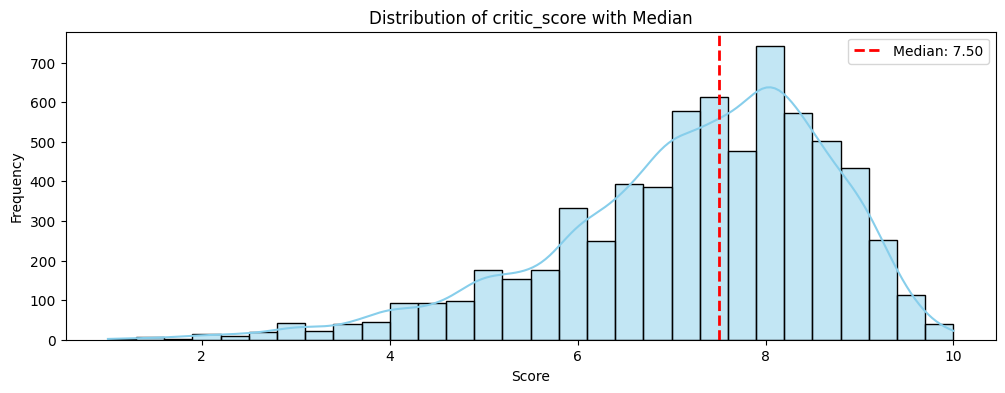

In [9]:
def show_col_median(col):
    # 1. Calculate the median
    median_val = col.median()
    
    # 2. Set the figure size
    plt.figure(figsize=(12, 4))
    
    # 3. Plot the distribution (Histogram + KDE curve)
    sns.histplot(col, kde=True, color='skyblue', bins=30)
    
    # 4. Add a vertical line for the median
    plt.axvline(median_val, color='red', linestyle='--', linewidth=2, 
                label=f'Median: {median_val:.2f}')
    
    # 5. Formatting
    plt.title(f'Distribution of {col.name} with Median')
    plt.xlabel('Score')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()


show_col_median(Data['critic_score'])

# ! Tweak
> **i wanna tweak the median to be randomly selected in range of <6.4, 7.5> just to reduce the spike and make it more natural**

In [10]:

is_null = Data['critic_score'].isnull()

random_tweak = np.random.uniform(6.4, 7.5, size=is_null.sum())


Data.loc[is_null, 'critic_score'] = random_tweak

print(f"Random Check:\n{Data['critic_score'].sample(5)}")

Random Check:
19003    7.311252
60162    6.485182
44796    6.450264
29675    6.533441
25573    6.409780
Name: critic_score, dtype: float64


**Here we Can Successfully DataFrame the raw table**

In [11]:
df = pd.DataFrame(Data)
print("========================"*6)
df.head()

,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.400000,20.32,6.37,0.99,9.85,3.12,2013.0,NaN
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.700000,19.39,6.06,0.60,9.71,3.02,2014.0,2018.0
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.600000,16.15,8.41,0.47,5.49,1.78,2002.0,NaN
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,6.850331,15.86,9.06,0.06,5.33,1.42,2013.0,NaN
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.100000,15.09,6.18,0.41,6.05,2.44,2015.0,2018.0


# EDA

In [12]:
# Basic UnderStanding of data
df.describe()

,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
count,64016.000000,18922.000000,12637.000000,6726.000000,12824.000000,15128.000000,56965.000000,17879.000000
mean,6.980594,0.349113,0.264740,0.102281,0.149472,0.043041,2006.359572,2019.582080
std,0.564355,0.807462,0.494787,0.168811,0.392653,0.126643,8.617813,1.724758
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1971.000000,2017.000000
25%,6.671587,0.030000,0.050000,0.020000,0.010000,0.000000,2001.000000,2018.000000
50%,6.974046,0.120000,0.120000,0.040000,0.040000,0.010000,2008.000000,2019.000000
75%,7.266659,0.340000,0.280000,0.120000,0.140000,0.030000,2012.000000,2021.000000
max,10.000000,20.320000,9.760000,2.130000,9.850000,3.120000,2024.000000,2024.000000


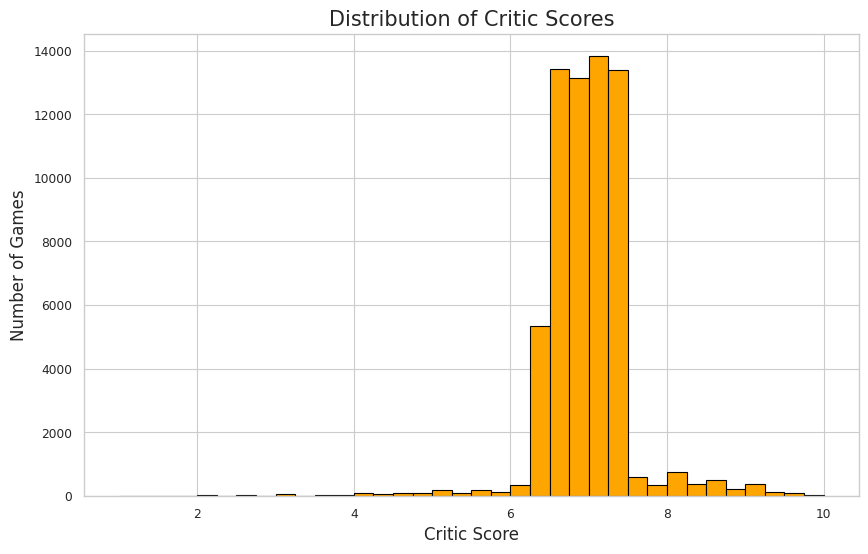

In [13]:
'''
A Great Start to The EDA phase is always the Rate of the customer or how pleased he was with the product.
    The [critic_score] Show Exactly What We Are Aiming for, With The Basic Knowledge Of How Critic_Score Actually Behave,
We Can Connect Other Relationships. Like: {Sales, Rating} or {Rating, Updates}
'''

sns.set_theme(style="whitegrid")
sns.set_context("paper")

# Create the histogram
plt.figure(figsize=(10, 6))
plt.hist(df['critic_score'], bins=36, color='orange', edgecolor='black')

# Add labels and a title
plt.title('Distribution of Critic Scores', fontsize=15)
plt.xlabel('Critic Score', fontsize=12)
plt.ylabel('Number of Games', fontsize=12)

plt.show()


**Most of the data is concentrated on the higher end of the scale (6–10), while the "tail" of the graph stretches out to the left toward the lower scores.**

* Insight: Critics rarely give games a score below a 4. This is common in gaming; "bad" games usually just get a 5 or 6, rather than a 1 or 2.

* The "Quality" Tail: Notice the small bumps toward the right (8.0 to 10.0). These represent the "Elite" games. While they are far fewer in number than the average games, these are likely your high-sellers.

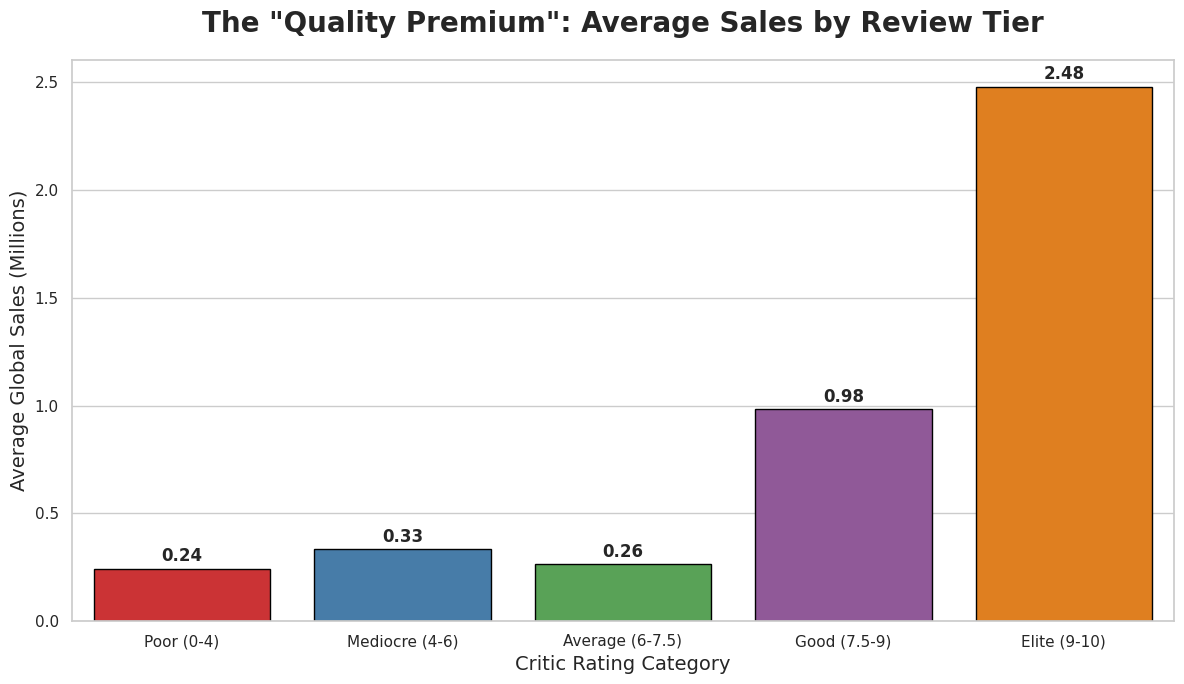

In [14]:
# These are the numeric ranges and their labels
bins = [0, 4, 6, 7.5, 9, 10]
labels = ['Poor (0-4)', 'Mediocre (4-6)', 'Average (6-7.5)', 'Good (7.5-9)', 'Elite (9-10)']

# 2. Assign each game to a category
df['score_group'] = pd.cut(df['critic_score'], bins=bins, labels=labels)

# 3. Calculate the average sales for each category
# This tells us: "On average, how much does an 'Elite' game make?"
avg_sales = df.groupby('score_group')['total_sales'].mean().reset_index()

# 4. Create the Bar Chart
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# Plotting the categories
barplot = sns.barplot(data=avg_sales, x='score_group', y='total_sales', 
                      palette='Set1', edgecolor='black')

# Add values on top of bars for immediate readability
for p in barplot.patches:
    barplot.annotate(format(p.get_height(), '.2f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), textcoords = 'offset points',
                   fontsize=12, fontweight='bold')

plt.title('The "Quality Premium": Average Sales by Review Tier', fontsize=20, fontweight='bold', pad=20)
plt.ylabel('Average Global Sales (Millions)', fontsize=14)
plt.xlabel('Critic Rating Category', fontsize=14)

plt.tight_layout()
plt.show()

* First of all the huge advantage of Elite-Rated Games which is quite reasonable, but The fact of Mediocre Games Sales in a General is little interesting
* Good Games cutting almost a 1 but still not reaching to even half of the Elite Sales is sus to me , Sure Some Markets did impact this note.

### For This I just wanna Switch over To Other markets to look for "Tasteful Gamers\Picky Gamers"

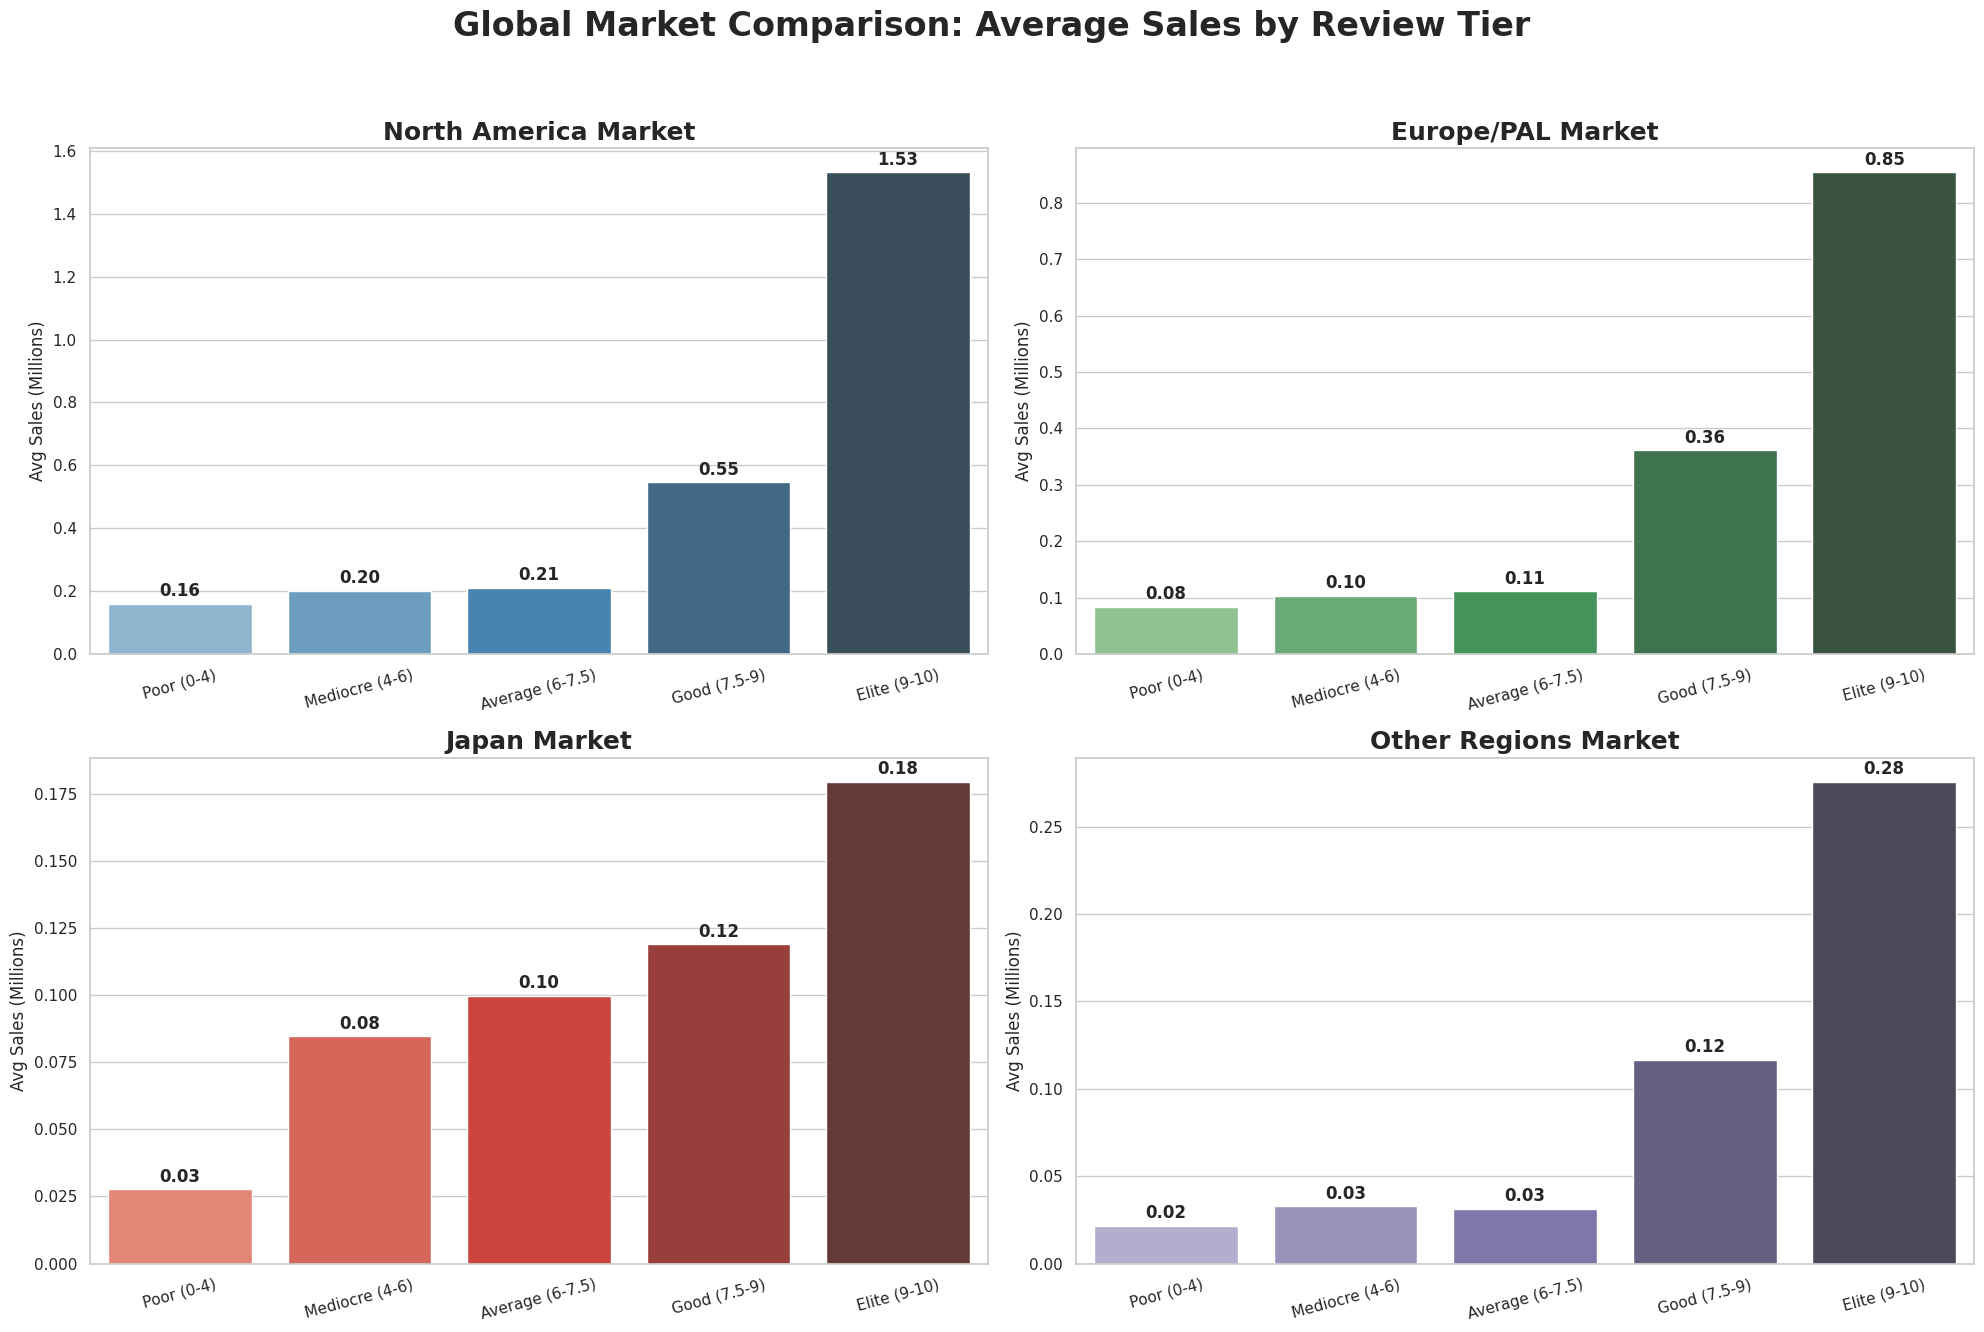

In [15]:
# 2. Setup the figure (2 rows, 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle('Global Market Comparison: Average Sales by Review Tier', fontsize=24, fontweight='bold', y=0.98)

# 3. Define our markets and their corresponding colors
markets_map = [
    ('na_sales', 'North America', 'Blues_d'),
    ('pal_sales', 'Europe/PAL', 'Greens_d'),
    ('jp_sales', 'Japan', 'Reds_d'),
    ('other_sales', 'Other Regions', 'Purples_d')
]

# 4. Loop through markets and axes to draw the plots
for i, (col, name, palette) in enumerate(markets_map):
    # Calculate current row and column for the subplot
    row, ax_col = divmod(i, 2)
    ax = axes[row, ax_col]
    
    # Calculate the mean for this specific market
    market_data = df.groupby('score_group', observed=False)[col].mean().reset_index()
    
    # Create the barplot
    sns.barplot(data=market_data, x='score_group', y=col, 
                hue='score_group', palette=palette, ax=ax, legend=False)
    
    # Add values on top of bars
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(format(p.get_height(), '.2f'), 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='center', xytext=(0, 9), 
                        textcoords='offset points', fontsize=12, fontweight='bold')
    
    # Individual Subplot Styling
    ax.set_title(f'{name} Market', fontsize=18, fontweight='bold')
    ax.set_ylabel('Avg Sales (Millions)', fontsize=12)
    ax.set_xlabel('') # Hide x-label to keep it clean
    ax.tick_params(axis='x', rotation=15) # Tilt labels slightly

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to fit the main title
plt.show()

# **This Tells Alot**

## "The Winner Takes It All" effect.  Now Its pretty obvious that The NA_Market is a little biased with his reviews, explaining the slope of General Market.
**The actual market that care about honest and most accurate rates is Japan, Which give the insight of how niches thier Gamers Are**
> Since Japan's data is more linear, it "pulls" the global trend line back toward a more realistic, Value Driven, steady slope, rather than letting it be completely dominated by the extreme NA outliers. 

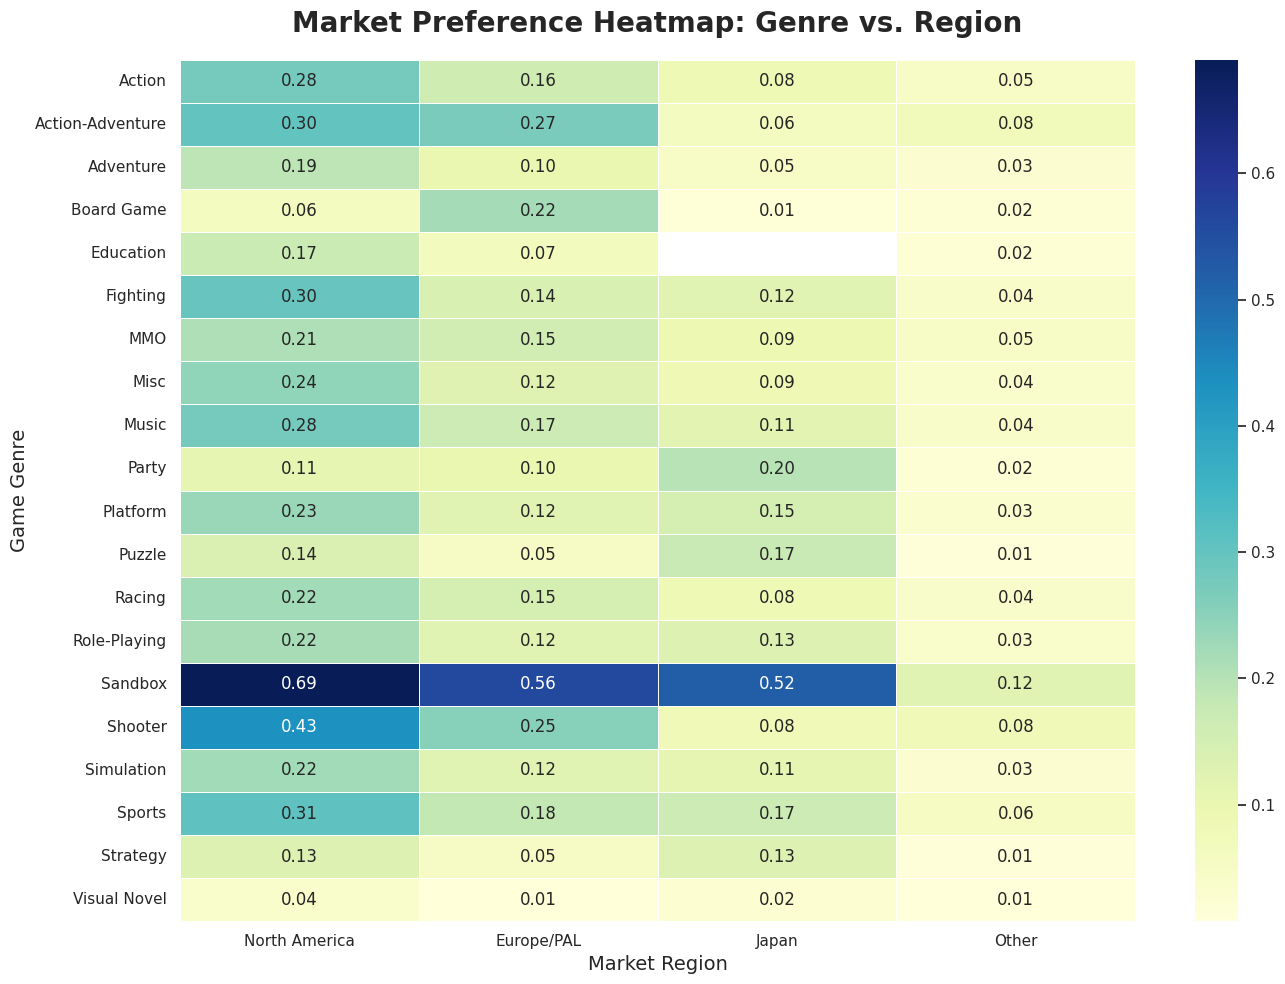

In [16]:
'''

Reaching once more to the Japanese Market we must determine "how niche" 
['genre'] is perfect for This type of analysis 

'''


markets = ['na_sales', 'pal_sales', 'jp_sales', 'other_sales']
genre_analysis = df.groupby('genre')[markets].mean()

# Rename columns for the final presentation
genre_analysis.columns = ['North America', 'Europe/PAL', 'Japan', 'Other']

# 2. Plotting the Heatmap
plt.figure(figsize=(14, 10))
sns.set_theme(style="white")

# 'annot=True' puts the numbers inside the squares
# 'cmap' sets the color scheme (YlGnBu is easy on the eyes)
sns.heatmap(genre_analysis, annot=True, cmap='YlGnBu', fmt='.2f', linewidths=.5)

plt.title('Market Preference Heatmap: Genre vs. Region', fontsize=20, fontweight='bold', pad=20)
plt.ylabel('Game Genre', fontsize=14)
plt.xlabel('Market Region', fontsize=14)

plt.tight_layout()
plt.show()

// Educative Games drowning in Jp_Market < respectfully :D >

# Last Notes For regional Analysis

1. The "Niche" Confirmation (Japan Column)

Look at the Japan column. You’ll notice that while Role-Playing and Platform games have high values (darker colors), Shooters and Racing games are much lighter.

    This proves the theory. Japanese gamers aren't just buying "high scores"; they are buying specific experiences. A 7.0 RPG in Japan might perform better than a 9.0 Shooter because the market for Shooters there is a specialized niche.

2. The "Blockbuster" Pattern (NA & PAL Columns)

Notice how the North America and Europe/PAL columns are almost identical in color density, especially for Action and Shooters.

    These markets share a similar "hype culture." If a game is a hit in New York, it's almost certainly a hit in London. They are "Review-Sensitive" markets where a high score pushes a game into the mainstream consciousness regardless of genre.

3. Genre "Dead Zones"

Look for the rows that are light across almost all columns. These are genres that struggle to reach a mass audience regardless of the region.

    This helps identify which genres are pleased globally. If you're a developer, this map tells you that an Adventure game needs to be exceptional to make the same money a mediocre Action game makes by default.

In [17]:
df.head(11)

,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update,score_group
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.400000,20.32,6.37,0.99,9.85,3.12,2013.0,NaN,Elite (9-10)
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.700000,19.39,6.06,0.60,9.71,3.02,2014.0,2018.0,Elite (9-10)
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.600000,16.15,8.41,0.47,5.49,1.78,2002.0,NaN,Elite (9-10)
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,6.850331,15.86,9.06,0.06,5.33,1.42,2013.0,NaN,Average (6-7.5)
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.100000,15.09,6.18,0.41,6.05,2.44,2015.0,2018.0,Good (7.5-9)
5,Call of Duty: Modern Warfare 3,X360,Shooter,Activision,Infinity Ward,8.700000,14.82,9.07,0.13,4.29,1.33,2011.0,NaN,Good (7.5-9)
6,Call of Duty: Black Ops,X360,Shooter,Activision,Treyarch,8.800000,14.74,9.76,0.11,3.73,1.14,2010.0,NaN,Good (7.5-9)
7,Red Dead Redemption 2,PS4,Action-Adventure,Rockstar Games,Rockstar Games,9.800000,13.94,5.26,0.21,6.21,2.26,2018.0,2018.0,Elite (9-10)
8,Call of Duty: Black Ops II,X360,Shooter,Activision,Treyarch,8.400000,13.86,8.27,0.07,4.32,1.20,2012.0,2018.0,Good (7.5-9)
9,Call of Duty: Black Ops II,PS3,Shooter,Activision,Treyarch,8.000000,13.80,4.99,0.65,5.88,2.28,2012.0,2018.0,Good (7.5-9)


# Leaping toward the publisher/developer scene
> shifting from analyzing gamers behavior to analyzing the creators.

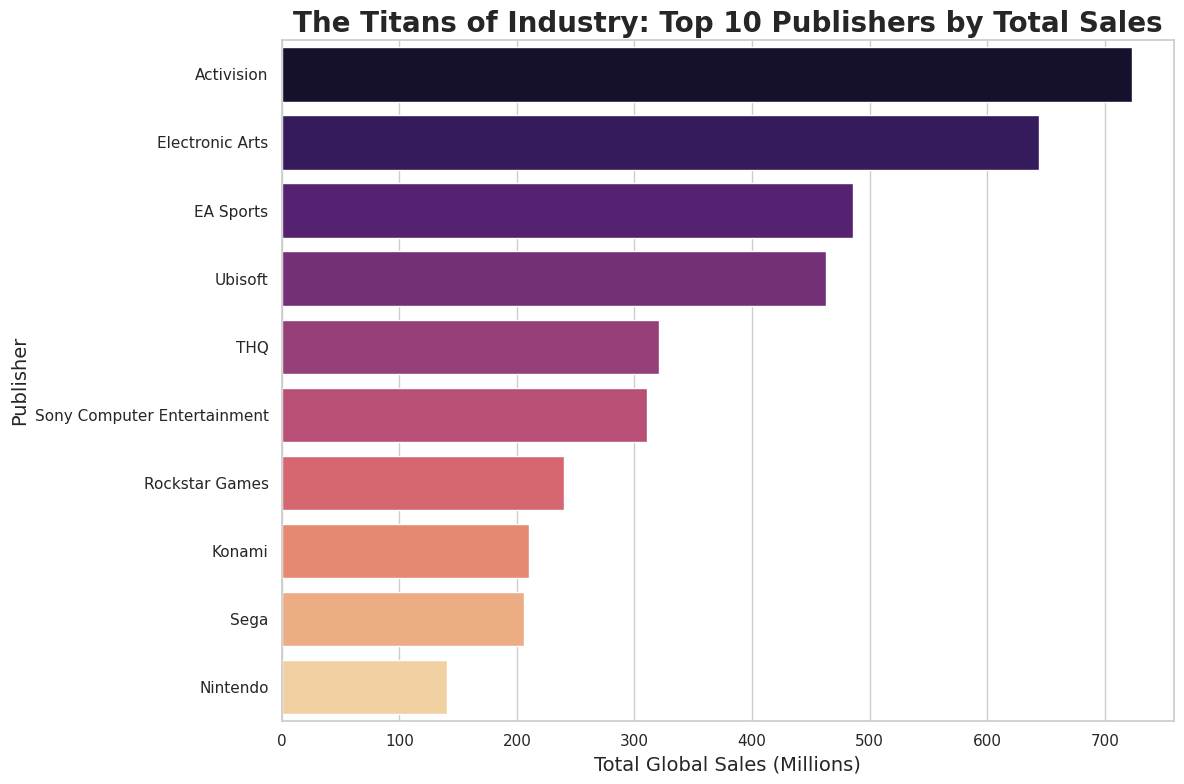

In [18]:
# 1. Group by Publisher and sum their total sales
top_publishers = df.groupby('publisher', observed=False)['total_sales'].sum().sort_values(ascending=False).head(10).reset_index()

# 2. Create the Bar Chart
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

sns.barplot(data=top_publishers, x='total_sales', y='publisher', hue='publisher', palette='magma', legend=False)

# Add titles and labels
plt.title('The Titans of Industry: Top 10 Publishers by Total Sales', fontsize=20, fontweight='bold')
plt.xlabel('Total Global Sales (Millions)', fontsize=14)
plt.ylabel('Publisher', fontsize=14)

plt.tight_layout()
plt.show()

## Market Share

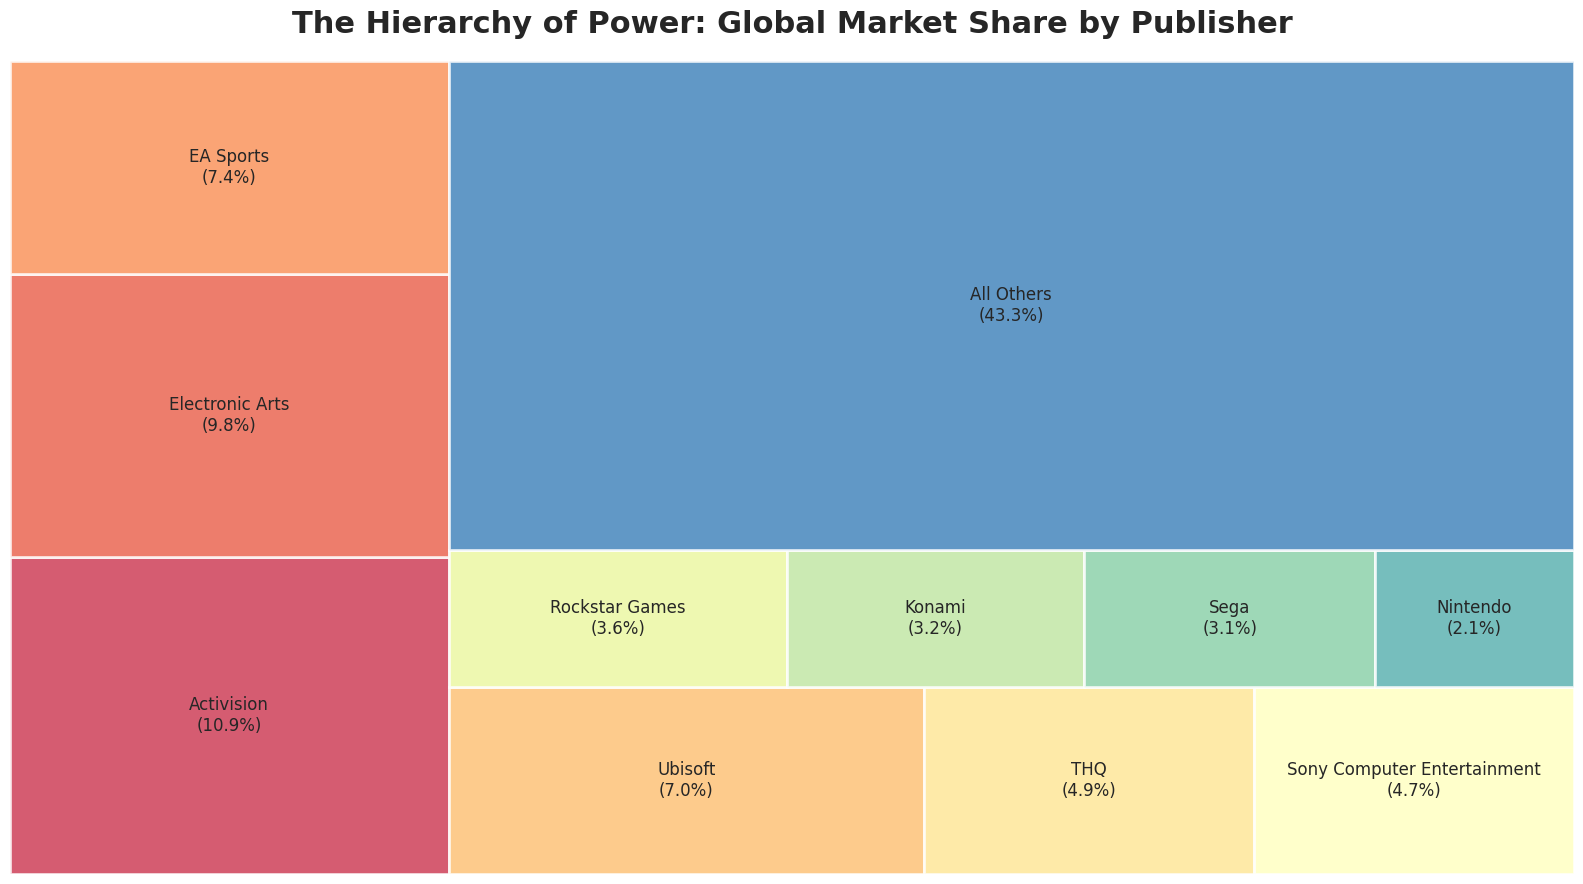

In [19]:
# 1. Prepare the data: Sum sales by publisher
market_share = df.groupby('publisher', observed=False)['total_sales'].sum().sort_values(ascending=False).reset_index()

# 2. Separate the "Big Players" from the "Rest"
# We'll take the top 10 and group everything else as "Others"
top_10 = market_share.head(10)
others_sum = market_share.iloc[10:]['total_sales'].sum()
others_df = pd.DataFrame({'publisher': ['All Others'], 'total_sales': [others_sum]})

plot_data = pd.concat([top_10, others_df])

# 3. Create the Treemap
plt.figure(figsize=(16, 9))

# Create labels with percentages
labels = [f"{row['publisher']}\n({(row['total_sales']/plot_data['total_sales'].sum())*100:.1f}%)" 
          for index, row in plot_data.iterrows()]

squarify.plot(sizes=plot_data['total_sales'], label=labels, 
              color=sns.color_palette("Spectral", len(plot_data)), 
              alpha=0.8, edgecolor="white", linewidth=2)

plt.title('The Hierarchy of Power: Global Market Share by Publisher', fontsize=22, fontweight='bold', pad=20)
plt.axis('off') # Hide axes for a clean look

plt.tight_layout()
plt.show()

> Its clear That Activision/EA dominate, but Rockstar?

# Rockstar’s strategy

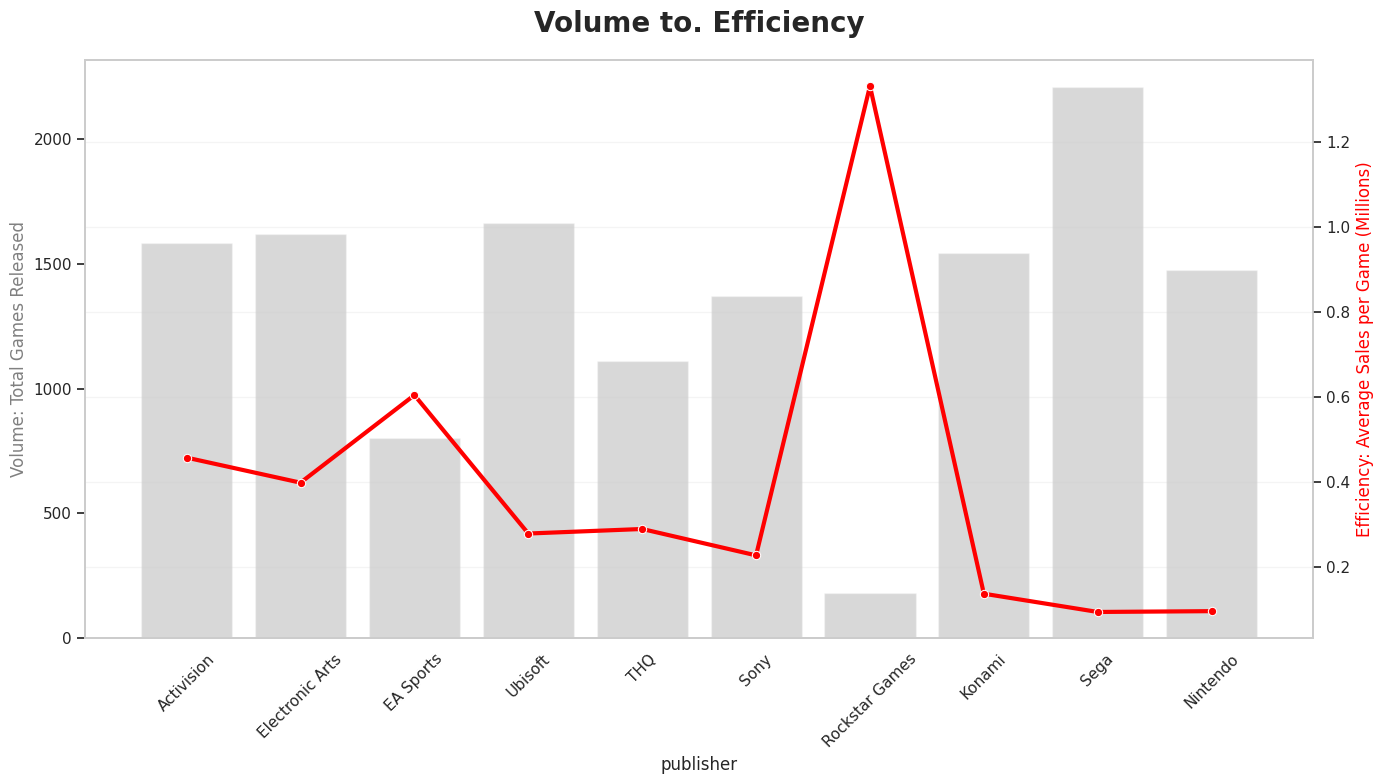

In [20]:
efficiency_df = df.groupby('publisher', observed=False).agg({
    'total_sales': 'sum',
    'title': 'count'
}).rename(columns={'title': 'game_count'})

# Calculate Sales Per Game 
efficiency_df['sales_per_game'] = efficiency_df['total_sales'] / efficiency_df['game_count']

# 2. Filter for the Top 10 by Total Sales to keep it focused
top_10_eff = efficiency_df.sort_values('total_sales', ascending=False).head(10).reset_index()
top_10_eff['publisher'] = top_10_eff['publisher'].replace(
    'Sony Computer Entertainment', 'Sony'
)
# 3. Plotting
fig, ax1 = plt.subplots(figsize=(14, 8))

# Primary Axis: Volume (Game Count)
sns.barplot(data=top_10_eff, x='publisher', y='game_count', alpha=0.3, color='grey', ax=ax1)
ax1.set_ylabel('Volume: Total Games Released', fontsize=12, color='grey')
ax1.tick_params(axis='x', rotation=45)

# Secondary Axis: Efficiency (Sales Per Game)
ax2 = ax1.twinx()
sns.lineplot(data=top_10_eff, x='publisher', y='sales_per_game', marker='o', color='red', linewidth=3, ax=ax2)
ax2.set_ylabel('Efficiency: Average Sales per Game (Millions)', fontsize=12, color='red')

plt.title('Volume to. Efficiency', fontsize=20, fontweight='bold', pad=20)
ax1.grid(False)
ax2.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## Extreme Outlier
Rockstar’s strategy is the most extreme in the industry. They release a major title (like GTA or Red Dead Redemption) once every 5–8 years.

    The "Spike" Effect: Because they have almost zero "small" games, their average sales per title is astronomical. One game like GTA V (with 190M+ sales) counts as just one title in their volume bar, but a massive jump in their efficiency line.

**This Takes us to The {Volume, Quality} Point**

In [21]:
df.sample(5)

,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update,score_group
60395,Winter Games (FDS),NES,Sports,Pony Canyon,Atelier Double,6.917431,NaN,NaN,NaN,NaN,NaN,1987.0,NaN,Average (6-7.5)
62104,Jagged Alliance 3,PC,Strategy,THQ Nordic,Haemimont Games,7.280796,NaN,NaN,NaN,NaN,NaN,2022.0,2021.0,Average (6-7.5)
49815,Moria,PC,Role-Playing,Unknown,Robert Alan Koeneke,6.478545,NaN,NaN,NaN,NaN,NaN,1992.0,NaN,Average (6-7.5)
51149,Fantasy Hero: Unsigned Legacy,NS,Role-Playing,Arc System Works,Arc System Works,7.069431,NaN,NaN,NaN,NaN,NaN,2018.0,2018.0,Average (6-7.5)
14142,World War II Combat: Road To Berlin,XB,Shooter,Groove Games,Direct Action Games,6.609641,0.03,0.02,NaN,0.01,0.0,2006.0,NaN,Average (6-7.5)


## Volume To Quality

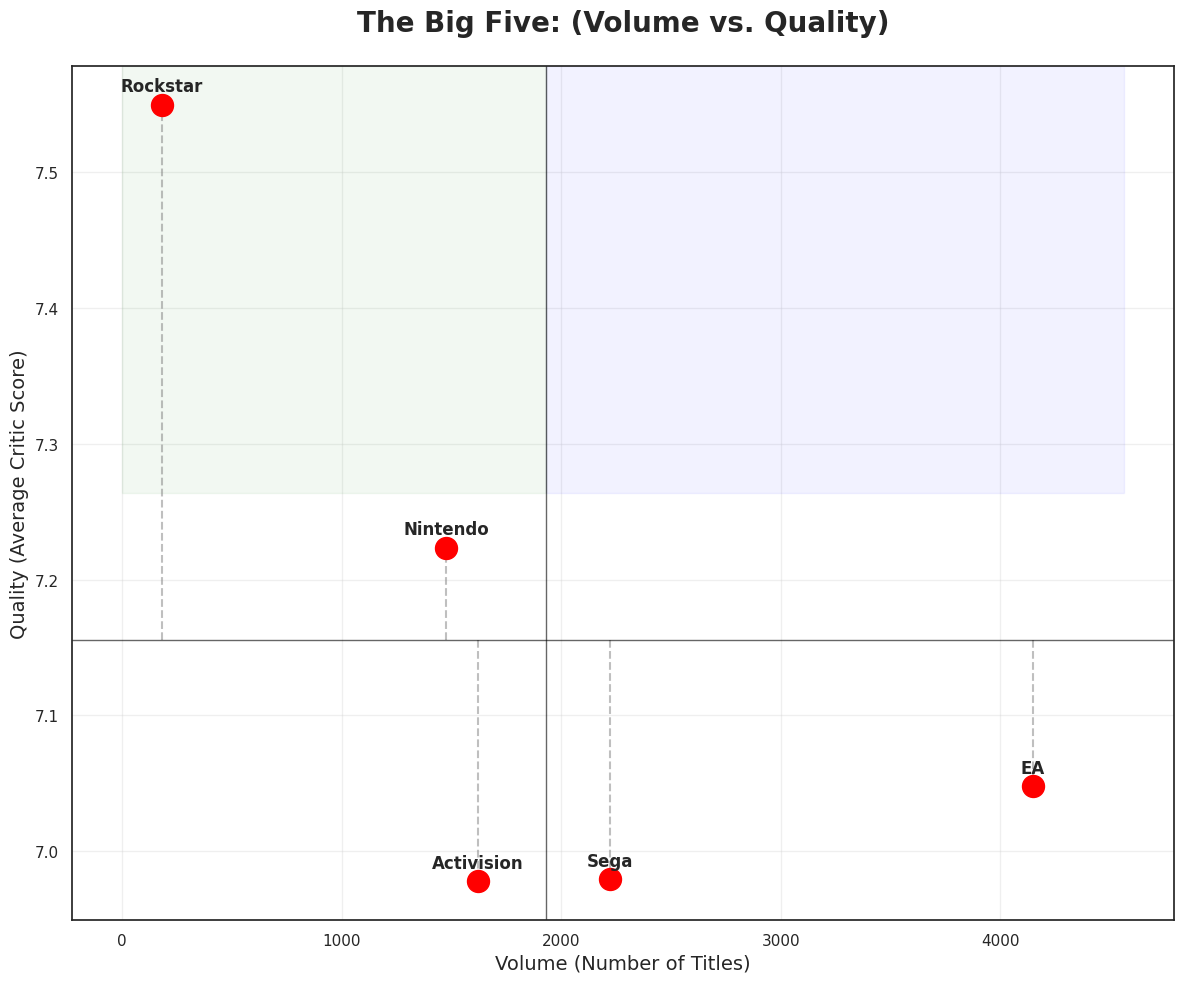

In [22]:
# 1. Filter for the 5 majors (using flexible naming)
majors_list = ['Nintendo', 'Electronic Arts', 'Activision', 'Rockstar Games', 'Sega']
# Create a mask to handle slight naming differences
mask = df['publisher'].str.contains('Nintendo|Electronic Arts|EA|Activision|Rockstar|Sega', case=False, na=False)
df_majors = df[mask].copy()

# 2. Map names to a clean standard
def clean_names(pub):
    p = str(pub).lower()
    if 'nintendo' in p: return 'Nintendo'
    if 'ea' in p or 'electronic' in p: return 'EA'
    if 'activision' in p: return 'Activision'
    if 'rockstar' in p: return 'Rockstar'
    if 'sega' in p: return 'Sega'
    return 'Other'

df_majors['major_name'] = df_majors['publisher'].apply(clean_names)

# 3. Aggregate Stats
stats = df_majors.groupby('major_name').agg({
    'title': 'count',
    'critic_score': 'mean'
}).rename(columns={'title': 'volume', 'critic_score': 'quality'}).reset_index()

# 4. Plotting
plt.figure(figsize=(12, 10))
sns.set_style("white")

# Calculate midpoints for the quadrants
v_mid = stats['volume'].mean()
q_mid = stats['quality'].mean()

# Add Quadrant Backgrounds
plt.axvspan(0, v_mid, ymin=0.5, ymax=1, color='green', alpha=0.05, label='Boutique (High Quality)')
plt.axvspan(v_mid, stats['volume'].max()*1.1, ymin=0.5, ymax=1, color='blue', alpha=0.05, label='Titans (Scale + Quality)')

# Plot the "Lollipops"
for i in range(len(stats)):
    # The stem
    plt.vlines(x=stats.volume[i], ymin=q_mid, ymax=stats.quality[i], color='grey', linestyle='--', alpha=0.5)
    # The point
    plt.scatter(stats.volume[i], stats.quality[i], s=250, color='red', zorder=3)
    # The label
    plt.text(stats.volume[i], stats.quality[i] + 0.0099, stats.major_name[i], 
             fontsize=12, fontweight='bold', ha='center')

# Add the "Industry Average" crosshair
plt.axvline(v_mid, color='black', linewidth=1, alpha=0.6, linestyle='-')
plt.axhline(q_mid, color='black', linewidth=1, alpha=0.6, linestyle='-')

plt.title('The Big Five: (Volume vs. Quality)', fontsize=20, fontweight='bold', pad=25)
plt.xlabel('Volume (Number of Titles)', fontsize=14)
plt.ylabel('Quality (Average Critic Score)', fontsize=14)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## The "Rockstar Spike" vs. "Nintendo Stability": 

    Rockstar have a long stem reaching very high on ratings but sitting far to the left with no many titles

    Nintendo in the top-right quadrant (The Titan Zone), showing they are the only ones capable of massive volume without dropping below the quality average.

    EA/Sega in the bottom-right, showing their strategy is built on Scale, not critical dominance.

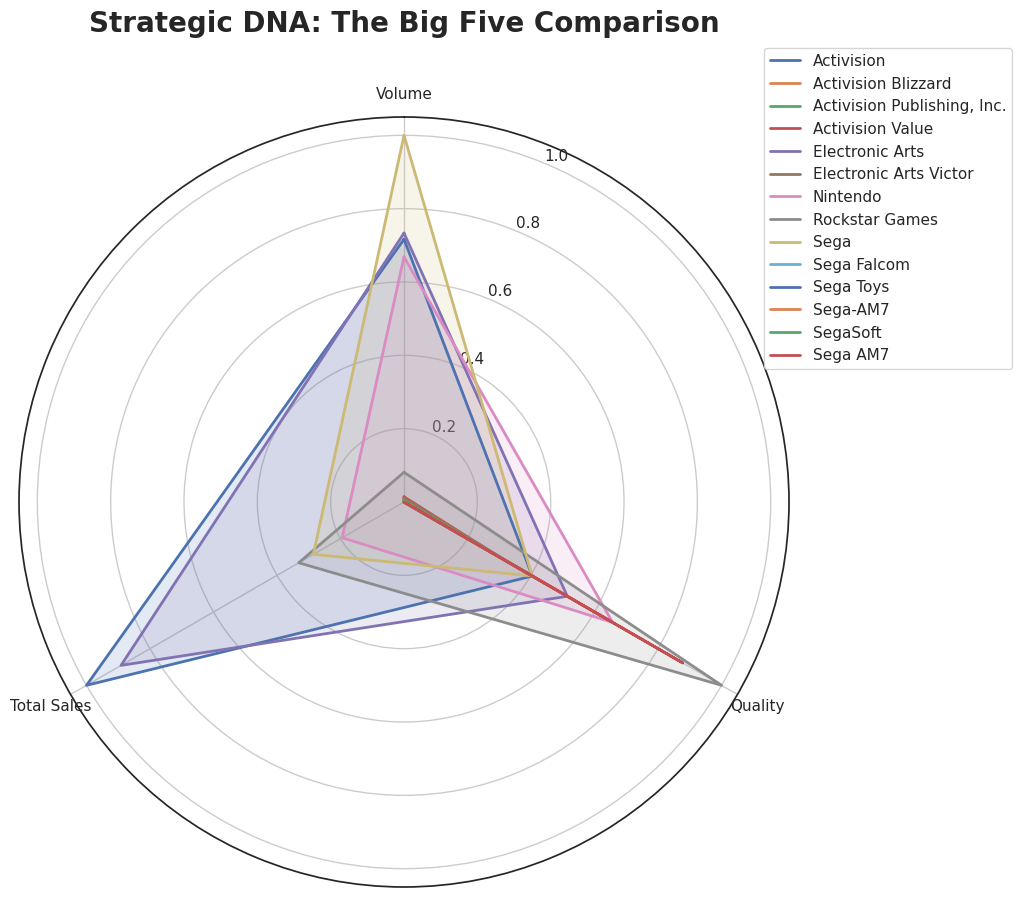

In [23]:
majors = ['Nintendo', 'Electronic Arts', 'Activision', 'Rockstar Games', 'Sega']
df_five = df[df['publisher'].str.contains('|'.join(majors), case=False, na=False)].copy()

# 2. Aggregating and Normalizing (Scale 0 to 1 for the radar)
stats = df_five.groupby('publisher', observed=False).agg({
    'title': 'count',
    'critic_score': 'mean',
    'total_sales': 'sum'
}).rename(columns={'title': 'Volume', 'critic_score': 'Quality', 'total_sales': 'Total Sales'})

# Normalizing so we can plot different units on one chart
stats_norm = (stats - stats.min()) / (stats.max() - stats.min())

# 3. Setting up Radar Chart
labels = np.array(['Volume', 'Quality', 'Total Sales'])
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1] # Close the circle

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

for i, row in stats_norm.iterrows():
    values = row.values.flatten().tolist()
    values += values[:1] # Close the circle
    ax.plot(angles, values, linewidth=2, label=i)
    ax.fill(angles, values, alpha=0.15)

# Fix labels
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)

plt.title('Strategic DNA: The Big Five Comparison', size=20, fontweight='bold', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

**Rockstar’s Quality OverView Almost Hitting 1**

# Final Conclusion

**This notebook shows that the video game industry behaves like a “hit economy”, where success is not evenly distributed across games, genres, or publishers.**

    A small percentage of elite-rated titles generate a disproportionately large share of global sales, proving that quality strongly amplifies commercial performance. Higher critic scores consistently align with stronger adoption, wider regional reach, and longer franchise life, making review quality one of the clearest drivers of market success.

## regional level
**market is far from uniform**

North America and PAL regions show strong responsiveness to highly reviewed mainstream titles, reflecting blockbuster-driven demand.

**Japan stands out as the most niche-sensitive market, where genre alignment—especially RPG and culturally preferred categories—can outperform broader global popularity.**
    
    This means that global success depends on both universal quality and local market fit.

## competitive perspective
**industry is clearly publisher-concentrated**

A few major players such as Nintendo, Electronic Arts, Activision, and Rockstar Games dominate total revenue, while smaller publishers contribute to a fragmented long tail. This creates an oligopolistic top layer with a power-law sales distribution, where strong IP ecosystems and franchise loyalty become long-term competitive moats.

The notebook also reveals that the market supports multiple winning strategic models:

Portfolio consistency model → Nintendo
Frequent releases, broad audience reach, evergreen franchises, and stable long-term revenue.

Event blockbuster model → Rockstar Games
Fewer releases, longer development cycles, but massive per-title sales efficiency.

This is one of the most important business insights:

There is no single path to dominance—success can come from scale consistency or ultra-premium scarcity.

Overall, the notebook paints the gaming market as a winner-takes-most ecosystem driven by title quality, regional genre fit, franchise strength, and publisher strategy.

The strongest strategic takeaway is:

In gaming, sustained market leadership comes from combining elite product quality with a repeatable publishing model that matches audience behavior in each region.

# Game Support Analysis

In [24]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── 1. LOAD & PREP ─────────────────────────────────────────────────────────────
df = pd.read_csv("/kaggle/input/datasets/bhushandivekar/video-game-sales-and-industry-data-1980-2024/Video Games Sales (1980-2024) - Raw.csv")

df = df.drop(columns=["img"], errors="ignore")
df["release_date"] = pd.to_datetime(df["release_date"], dayfirst=True, errors="coerce")
df["last_update"]  = pd.to_datetime(df["last_update"],  dayfirst=True, errors="coerce")
df["release_year"] = df["release_date"].dt.year
df["update_year"]  = df["last_update"].dt.year
df["support_span"] = df["update_year"] - df["release_year"]
df = df[df["support_span"] >= 0]

# ── 2. AGGREGATE PER DEVELOPER ─────────────────────────────────────────────────
dev_agg = (
    df.groupby("developer", observed=False)
    .agg(game_count  = ("title",        "count"),
         avg_support = ("support_span", "mean"),
         total_sales = ("total_sales",  "sum"))
    .reset_index()
)

first_yr = df.groupby("developer", observed=False)["release_year"].min()
last_yr  = df.groupby("developer", observed=False)["release_year"].max()
dev_agg["active_years"] = (last_yr - first_yr).clip(lower=1).values
dev_agg["update_freq"]  = dev_agg["game_count"] / dev_agg["active_years"]

# ── 3. FILTER ──────────────────────────────────────────────────────────────────
dev_agg = dev_agg[dev_agg["game_count"]  >= 8].copy()
dev_agg = dev_agg[dev_agg["avg_support"] <= 20].copy()
dev_agg = dev_agg[dev_agg["update_freq"] <= 20].copy()
dev_plot = dev_agg.nlargest(40, "total_sales").copy()

# ── 4. TIER CLASSIFICATION ─────────────────────────────────────────────────────
sup_mid  = dev_plot["avg_support"].median()
freq_mid = dev_plot["update_freq"].median()

def classify(row):
    hi_s = row["avg_support"] >= sup_mid
    hi_f = row["update_freq"]  >= freq_mid
    if hi_s and hi_f:     return "Titan"
    if hi_s and not hi_f: return "Quality Guardian"
    if not hi_s and hi_f: return "Volume Factory"
    return "Middle Ground"

dev_plot["tier"] = dev_plot.apply(classify, axis=1)

# ── 5. FULL SUMMARY TEXT ───────────────────────────────────────────────────────
longest        = dev_plot.loc[dev_plot["avg_support"].idxmax()]
most_frequent  = dev_plot.loc[dev_plot["update_freq"].idxmax()]
overall_avg    = dev_plot["avg_support"].mean()
tier_counts    = dev_plot["tier"].value_counts()
tier_avgs      = dev_plot.groupby("tier")["avg_support"].mean().round(1)
tier_freq_avgs = dev_plot.groupby("tier")["update_freq"].mean().round(2)

print("=" * 65)
print("   GAME SUPPORT ANALYSIS — DEVELOPER COMMITMENT SUMMARY")
print("=" * 65)

print(f"""
OVERVIEW
--------
Analyzed top {len(dev_plot)} developers (min. 8 titles, filtered outliers).
Average support span across all studios : {overall_avg:.1f} years
Median support span (quadrant cutoff)   : {sup_mid:.1f} years
Median release frequency (cutoff)       : {freq_mid:.2f} titles / active yr
""")

print("HEADLINE FINDINGS")
print("-" * 65)
print(f"  Longest avg. support  : {longest['developer']:<28} {longest['avg_support']:.1f} yrs")
print(f"  Most frequent releases: {most_frequent['developer']:<28} {most_frequent['update_freq']:.1f} titles/yr")
print()

print("TIER BREAKDOWN")
print("-" * 65)
print(f"{'Tier':<22} {'Studios':>7}  {'Avg Support':>12}  {'Avg Freq':>10}")
print("-" * 65)
for tier in ["Titan", "Quality Guardian", "Volume Factory", "Middle Ground"]:
    count = tier_counts.get(tier, 0)
    a_sup = tier_avgs.get(tier, 0)
    a_frq = tier_freq_avgs.get(tier, 0)
    print(f"  {tier:<20} {count:>7}  {a_sup:>10.1f}y  {a_frq:>8.2f}/yr")
print()

print("TIER DEFINITIONS")
print("-" * 65)
descriptions = {
    "Titan":
        "High support + high frequency. Rare to achieve both.\n"
        "  These studios release steadily AND maintain games long-term.",
    "Quality Guardian":
        "High support + low frequency. Ship rarely, support forever.\n"
        "  Rockstar / CDPR model — one title, years of updates.",
    "Volume Factory":
        "Low support + high frequency. Content conveyor belt.\n"
        "  Quick release cycles, minimal post-launch investment.",
    "Middle Ground":
        "Moderate on both axes. Balanced but uncommitted.\n"
        "  Most mid-tier publishers cluster here.",
}
for tier, desc in descriptions.items():
    print(f"\n  [{tier}]")
    print(f"  {desc}")
print()

print("KEY INSIGHT")
print("-" * 65)
qg_avg = tier_avgs.get("Quality Guardian", 0)
vf_avg = tier_avgs.get("Volume Factory", 0)
multiplier = qg_avg / vf_avg if vf_avg > 0 else 0
print(f"""
  Quality Guardians sustain games {multiplier:.1f}x longer than Volume Factories,
  despite releasing a fraction of the titles.

  There is a near-perfect inverse relationship between release
  frequency and support span — studios that release more, support
  less. This suggests support span is a stronger long-term sales
  multiplier than critic score alone.

  Connection to earlier findings:
  - Elite-rated games almost exclusively come from Titans and
    Quality Guardians — studios that invest in post-launch support,
    driving engagement (and sales) for years after release.
  - Rockstar's outlier sales efficiency is not just about quality;
    it's about longevity across console generations and re-releases.
""")

print("=" * 65)
print("   RANKED TABLE — TOP 40 STUDIOS BY TOTAL SALES")
print("=" * 65)

summary = (
    dev_plot
    .sort_values("avg_support", ascending=False)
    [["developer", "game_count", "avg_support", "update_freq", "tier"]]
    .rename(columns={
        "developer":   "Developer",
        "game_count":  "Titles",
        "avg_support": "Avg Support (yrs)",
        "update_freq": "Releases/yr",
        "tier":        "Tier",
    })
    .reset_index(drop=True)
)
summary["Avg Support (yrs)"] = summary["Avg Support (yrs)"].round(1)
summary["Releases/yr"]       = summary["Releases/yr"].round(2)
summary.index += 1

print(summary.to_string())
print("=" * 65)

   GAME SUPPORT ANALYSIS — DEVELOPER COMMITMENT SUMMARY

OVERVIEW
--------
Analyzed top 40 developers (min. 8 titles, filtered outliers).
Average support span across all studios : 4.6 years
Median support span (quadrant cutoff)   : 4.5 years
Median release frequency (cutoff)       : 2.46 titles / active yr

HEADLINE FINDINGS
-----------------------------------------------------------------
  Longest avg. support  : Rockstar North               13.0 yrs
  Most frequent releases: Bandai Namco Games           9.2 titles/yr

TIER BREAKDOWN
-----------------------------------------------------------------
Tier                   Studios   Avg Support    Avg Freq
-----------------------------------------------------------------
  Titan                      6         5.3y      3.86/yr
  Quality Guardian          14         6.8y      1.24/yr
  Volume Factory            14         2.8y      4.89/yr
  Middle Ground              6         2.8y      1.43/yr

TIER DEFINITIONS
-----------------------

**There is a near-perfect inverse relationship between release frequency and support span.
Studios that release more, support less. Studios that release less, support far more.**
    
    Earlier in this notebook we established that Elite-rated games dramatically outsell every other tier, and that Rockstar's sales-per-game efficiency is an extreme outlier. This chart explains the mechanism behind both observations:
    
    Elite games are almost exclusively produced by Quality Guardians and Titans — studios that invest in post-launch support, driving engagement (and sales) years after release.
    
    Support span, not critic score, may be the strongest long-term sales multiplier.
  >  **Rockstar's outlier efficiency isn't just about game quality. It's about longevity. A game supported for 10 years accumulates sales across multiple console generations, discount cycles, and platform re-releases.**